In [ ]:
import os
import sys
import pandas as pd
import argparse
import warnings
from utils import *
from torch import nn
import copy
from tqdm import tqdm
import random 
from data_loader import *
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
import numpy as np
from http import HTTPStatus
import dashscope
from xgboost import XGBRegressor
from dashscope import Generation
import json
# import openai
from deepseek import DeepSeekClient
import os
from train import *
from model import GurobiPowerScheduler
import pickle
from together import Together
from openai import OpenAI
warnings.filterwarnings("ignore")
#set deepseek and openai API keys


dashscope.api_key = 'YOUR KEY'
DEEPSEEK_API_KEY = 'YOUR KEY'
OPENAI_API_KEY = 'YOUR KEY'
LLAMA_API_KEY='YOUR KEY'

In [3]:
# with open('../Result cost analysis/Tree+LP/Qwen_new.pkl', 'rb') as f:
#     result_qwen=pickle.load(f)
# result_qwen['cost_ideal']=cost_list_ideal

# with open('../Result cost analysis/Tree+LP/LlamaEN.pkl', 'rb') as f:
#     result_llama=pickle.load(f)
# result_llama['cost_ideal']=cost_list_ideal

# with open('../Result cost analysis/Tree+LP/Deepseek.pkl', 'rb') as f:
#     result_ds=pickle.load(f)
# result_ds['cost_ideal']=cost_list_ideal

# with open('../../Result EN copy/Tree+LP/Deepseek.pkl', 'wb') as f:
#     pickle.dump(result_ds, f)

# with open('../../Result EN copy/Tree+LP/Llama.pkl', 'wb') as f:
#     pickle.dump(result_llama, f)

# with open('../../Result EN copy/Tree+LP/Qwen.pkl', 'wb') as f:
#     pickle.dump(result_qwen, f)


In [4]:
parser_train = argparse.ArgumentParser()
parser_train.add_argument('--seq_len', type=int, default=24*7)
parser_train.add_argument('--pred_len', type=int, default=24)
parser_train.add_argument('--label_len', type=int, default=0)
parser_train.add_argument('--train_length', type=int, default=17376)
parser_train.add_argument('--target', type=str, default='target')
parser_train.add_argument('--scale', type=bool, default=True)
parser_train.add_argument('--inverse', type=bool, default=True)
parser_train.add_argument('--num_epochs', type=int, default=1000)
parser_train.add_argument('--mode', type=str, default='seq2seq')
parser_train.add_argument('--quantiles', type=list, default=[0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6,0.65,0.7,0.75,0.8,0.85,0.9,0.95])
parser_train.add_argument('--lr', type=float, default=1e-3)
parser_train.add_argument('--patience', type=int, default=5)
parser_train.add_argument('--hidden_layers', type=list, default=[128,128,128])
parser_train.add_argument('--e2e_num_epochs', type=int, default=5)
parser_train.add_argument('--e2e_ft_lr', type=float, default=1e-6)
parser_train.add_argument('--e2e_lr', type=float, default=1e-7)#1e-7
parser_train.add_argument('--ft_lr', type=float, default=1e-4)
parser_train.add_argument('--batch_size', type=int, default=16)
parser_train.add_argument('--device', type=str, default='cuda:0' if torch.cuda.is_available() else 'cpu')
parser_train.add_argument('--epsion_p', type=float, default=1e1)
parser_train.add_argument('--epsion_l', type=float, default=1e1)
parser_train.add_argument('--metric_list', type=list, default=['pinball_loss','winkler_score_0.1','MAE','RMSE'])


parser_train.add_argument('--N_g', type=int, default=3)
parser_train.add_argument('--T', type=int, default=24)
parser_train.add_argument('--N', type=int, default=25)
parser_train.add_argument('--x_max', type=int, default=[1500,1800,2000])
parser_train.add_argument('--x_min', type=int, default=[0,0,0])
parser_train.add_argument('--z_pos_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_neg_max', type=list, default=[500,700,800])
parser_train.add_argument('--z_pos_min', type=int, default=0)
parser_train.add_argument('--z_neg_min', type=int, default=0)
parser_train.add_argument('--r_neg', type=int, default=[800,800,500])
parser_train.add_argument('--r_pos', type=int, default=[800,800,500])
parser_train.add_argument('--alpha', type=list, default=[0.03 for i in range(24)]+[0.028 for i in range(24)]+[0.032 for i in range(24)])
parser_train.add_argument('--alpha_pos', type=list, default=[0.02 for i in range(24)]+[0.018 for i in range(24)]+[0.022 for i in range(24)])
parser_train.add_argument('--alpha_neg', type=list, default=[0.01 for i in range(24)]+[0.009 for i in range(24)]+[0.011 for i in range(24)])

parser_train.add_argument('--rho_z_pos', type=list, default=[0.05 for i in range(24)]+[0.045 for i in range(24)]+[0.055 for i in range(24)])
parser_train.add_argument('--rho_z_neg', type=list, default=[0.01 for i in range(24)]+[0.008 for i in range(24)]+[0.012 for i in range(24)])

parser_train.add_argument('--rho_r_pos', type=list, default=[0.1 for i in range(24)])
parser_train.add_argument('--rho_r_neg', type=list, default=[0.05 for i in range(24)])

parser_train.add_argument('--price_ratio_large', type=float, default=2.5)
parser_train.add_argument('--price_ratio_small', type=float, default=0.8)
parser_train.add_argument('--flag_dynamic_price', type=bool, default=False)
parser_train.add_argument('--flag_dynamic_mode', type=int, default=0)
parser_train.add_argument('--upper_quantiles', type=float, default=0.95)
parser_train.add_argument('--lower_quantiles', type=float, default=0.05)
parser_train.add_argument('--epsion', type=float, default=1)
parser_train.add_argument('--LLM_type', type=str, default='Llama') #'euclidean' 'manhattan'
args = parser_train.parse_args(args=[])

In [32]:
dir(train_load_data.scaler_y)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_feature_names',
 '_check_n_features',
 '_get_param_names',
 '_get_tags',
 '_more_tags',
 '_repr_html_',
 '_repr_html_inner',
 '_repr_mimebundle_',
 '_reset',
 '_validate_data',
 'clip',
 'copy',
 'data_max_',
 'data_min_',
 'data_range_',
 'feature_names_in_',
 'feature_range',
 'fit',
 'fit_transform',
 'get_feature_names_out',
 'get_params',
 'inverse_transform',
 'min_',
 'n_features_in_',
 'n_samples_seen_',
 'partial_fit',
 'scale_',
 'set_params',
 'transform']

In [33]:
train_load_data.scaler_y.data_max_

array([5224., 5224., 5224., 5224., 5224., 5224., 5224., 5224., 5224.,
       5224., 5224., 5224., 5224., 5224., 5224., 5224., 5224., 5224.,
       5224., 5224., 5224., 5224., 5224., 5224.])

In [34]:
train_load_data.scaler_y.data_min_

array([1979., 1979., 1979., 1979., 1979., 1979., 1979., 1979., 1979.,
       1979., 1979., 1979., 1979., 1979., 1979., 1979., 1979., 1979.,
       1979., 1979., 1979., 1979., 1979., 1979.])

In [5]:
train_load_data,train_load_loader=get_load_data(args,flag='train')
val_load_data,val_load_loader=get_load_data(args,flag='val')
test_load_data,test_load_loader=get_load_data(args,flag='test')

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

X_test=train_load_data.inverse_transform_X(test_load_data.X)
X_train=train_load_data.inverse_transform_X(train_load_data.X)
X_val=train_load_data.inverse_transform_X(val_load_data.X)
history_X_test=X_test[:,3:99]
history_X_train=X_train[:,3:99]
history_X_val=X_val[:,3:99]
print(np.shape(X_test))
print(np.shape(history_X_test))
print(np.shape(X_train))
print(np.shape(history_X_train))
print(np.shape(X_val))
print(np.shape(history_X_val))

(26113, 219)
(26113, 219)
(26113, 219)
(29, 195)
(29, 96)
(358, 195)
(358, 96)
(335, 195)
(335, 96)


In [6]:
from utils import *
combined_train_data,combined_train_loader,combined_val_data,combined_val_loader,combined_test_data,combined_test_loader,combined_fine_tune_data,combined_fine_tune_loader = obtain_price(args,train_load_data,val_load_data,test_load_data)
data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

optimization_module = GurobiPowerScheduler(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)

x_max_list (72,)
r_pos_list (69,)
r_neg_list (69,)
[1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]


In [7]:
# from xgboost import XGBRegressor
# from sklearn.multioutput import MultiOutputRegressor
# input_size=train_load_data.X.shape[-1]

# set_seed(42)
# output_size=24
# #objective='reg:squarederror',
# model_xgb = MultiOutputRegressor(XGBRegressor(
#     max_depth=6,           # 降低树深度（默认6，建议3-5）
#     min_child_weight=5,    # 叶子节点最小样本权重和（防止过细分裂）
#     gamma=0.01,            # 分裂最小损失下降（越大越保守）
#     reg_lambda=5,        # L2正则化（默认1，可增大）
#     n_estimators=50
# )
# )
# model_xgb.fit(train_load_data.X, train_load_data.y)

# test_pred_nor=model_xgb.predict(test_load_data.X)
# test_pred= train_load_data.inverse_transform(test_pred_nor)
# test_actual_nor=test_load_data.y#.reshape(-1,1)
# actual_load_test = train_load_data.inverse_transform(test_actual_nor)

# cost_list_test=[]
# cost_list_ideal=[]
# for i in range(len(test_pred)):
#     forecast=test_pred[i]
#     actual=actual_load_test[i]
#     _,_,costs_org=optimization_module.forward(forecast, actual)
#     _,_,costs_ideal=optimization_module.forward(actual, actual)
#     cost_list_test.append(costs_org)
#     cost_list_ideal.append(costs_ideal)
    

# print(MAE(test_pred,actual_load_test),RMSE(test_pred,actual_load_test),MAPE(test_pred,actual_load_test))


import xgboost as xgb

set_seed(42)

Xtr = train_load_data.X
train_actual_nor = train_load_data.y          # shape: (n_samples, 24)
Xte = test_load_data.X
# Yte = test_load_data.y
test_actual_nor = test_load_data.y
dtr = xgb.DMatrix(Xtr, label=train_actual_nor)
dte = xgb.DMatrix(Xte, label=test_actual_nor)

params = {
    "objective": "reg:squarederror",
    "tree_method": "hist",

    "max_depth": 5,
    "min_child_weight": 5,
    "gamma": 0.01,
    "lambda": 5,              # 等价 reg_lambda
    "eta": 0.05,              # 学习率（建议加上）
    "subsample": 0.9,
    "colsample_bytree": 0.9,

    # 关键：一次输出 24 维
    "multi_strategy": "multi_output_tree",   # 或 "one_output_per_tree"
}

num_boost_round = 300  # 你原来 n_estimators=100，这里可以适当调大配合 eta
model_xgb = xgb.train(params, dtr, num_boost_round=num_boost_round)

test_pred_nor = model_xgb.predict(dte)                 # (n_samples, 24)
test_pred = train_load_data.inverse_transform(test_pred_nor)
actual_load_test = train_load_data.inverse_transform(test_actual_nor)

cost_list_test, cost_list_ideal = [], []
for i in range(len(test_pred)):
    forecast = test_pred[i]
    actual = actual_load_test[i]
    _, _, costs_org = optimization_module.forward(forecast, actual)
    _, _, costs_ideal = optimization_module.forward(actual, actual)
    cost_list_test.append(costs_org)
    cost_list_ideal.append(costs_ideal)

print(MAE(test_pred, actual_load_test),
      RMSE(test_pred, actual_load_test),
      MAPE(test_pred, actual_load_test))

Set parameter Username
Academic license - for non-commercial use only - expires 2026-08-26
127.52760227247217 171.0300123862584 0.035623204741314925


In [8]:


class DeterministicLayer:
    def __init__(self, args):
        """日前调度层初始化"""
        self.T = args.T
        self.N_g = args.N_g
        self.N = args.N
        
        # 转换参数为NumPy数组
        self.x_max = np.array(args.x_max, dtype=np.float64)
        self.x_min = np.array(args.x_min, dtype=np.float64)
        print(self.x_max)
        print(self.x_min)
        self.r_pos = np.array(args.r_pos, dtype=np.float64)
        self.r_neg = np.array(args.r_neg, dtype=np.float64)
        self.z_pos_max = np.array(args.z_pos_max, dtype=np.float64)
        self.z_neg_max = np.array(args.z_neg_max, dtype=np.float64)
        self.min_up_time = np.array(args.min_up_time, dtype=np.int32)  # 最小开机时间
        
        # 预计算约束矩阵
        self._precompute_matrices()
    
    def _precompute_matrices(self):
        """预计算所有约束矩阵（完全对应CVXPY版本）"""
        T = self.T
        N_g = self.N_g
        
        # 单位矩阵
        I_N_g = np.eye(N_g * T, dtype=np.float64)
        I = np.eye(T, dtype=np.float64)
        
        # Ramp矩阵 (T-1) x T
        Ramp_matrix = np.zeros((T - 1, T), dtype=np.float64)
        for i in range(T - 1):
            Ramp_matrix[i, i] = 1
            if i + 1 < T:
                Ramp_matrix[i, i + 1] = -1
        
        # Ramp_matrix_combined: 3(T-1) x 3T
        zero_block = np.zeros((T - 1, T), dtype=np.float64)
        Ramp_matrix_combined = np.vstack([
            np.hstack([Ramp_matrix, zero_block, zero_block]),
            np.hstack([zero_block, Ramp_matrix, zero_block]),
            np.hstack([zero_block, zero_block, Ramp_matrix])
        ])
        
        # I_combined: T x 3T
        I_combined = np.hstack([I, I, I])
        
        # A_eq_l (功率平衡约束矩阵)
        self.A_eq_l = I_combined
        
        # A_uq_x (发电机约束矩阵)
        row1 = I_N_g
        row2 = Ramp_matrix_combined
        row3 = -Ramp_matrix_combined
        self.A_uq_x = np.vstack([row1, row2,row3])
        
        x_max_list=np.zeros(N_g * T, dtype=np.float64)
        for i in range(N_g):
             x_max_list[i*T:(i+1)*T] = self.x_max[i]*np.ones(T, dtype=np.float64)
    
    def solve(self, l_for, alpha, alpha_z):
        # 转换输入为NumPy数组并确保非负
        l_for = np.asarray(l_for, dtype=np.float64)
        alpha = np.asarray(alpha, dtype=np.float64)
        alpha_z = np.asarray(alpha_z, dtype=np.float64)
        
        # 创建Gurobi模型
        model = gp.Model("day_ahead_scheduling")
        model.setParam('OutputFlag', 0)  # 关闭输出
        
        # 添加决策变量
        x = model.addMVar(self.N_g * self.T, lb=0.0, name="x")
        z_max = model.addMVar(2 * self.N_g * self.T, lb=0.0, name="z_max")
        #u = model.addMVar(self.N_g * self.T, vtype=GRB.BINARY, name="u")  # 机组启停状态
        
        # 原有约束
        model.addConstr(self.A_eq_l @ x == l_for, "power_balance")
                    
        for g in range(self.N_g):
            for t in range(self.T):
                idx = g * self.T + t
                model.addConstr(x[idx] <= self.x_max[g], f"on_off_upper_{g}_{t}")
                model.addConstr(x[idx] >= self.x_min[g], f"on_off_lower_{g}_{t}")
                model.addConstr(x[idx] + z_max[idx] <= self.x_max[g], f"non_negative_{g}_{t}")
                model.addConstr(x[idx] - z_max[self.N_g * self.T + idx] >= self.x_min[g], f"non_negative_{g}_{t}")
                model.addConstr(z_max[idx] <= self.z_pos_max, f"z_pos_non_negative_{g}_{t}")
                model.addConstr(z_max[self.N_g * self.T + idx] <= self.z_neg_max, f"z_neg_non_negative_{g}_{t}")
                if t > 0:
                    model.addConstr(x[idx]-x[idx-1] <= self.r_pos[g], f"ramp_up_{g}_{t}")
                    model.addConstr(x[idx-1]-x[idx] <= self.r_neg[g], f"ramp_down_{g}_{t}")

        obj = alpha @ x +  alpha_z @ z_max
        model.setObjective(obj, GRB.MINIMIZE)
        
        # 求解
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            return x.X, z_max.X, u.X
        else:
            raise RuntimeError(f"日前调度优化失败，状态码: {model.status}")


In [9]:
class DeterministicLayer_milp:
    def __init__(self, args):
        """日前调度层初始化"""
        self.T = args.T
        self.N_g = args.N_g
        self.N = args.N
        
        # 转换参数为NumPy数组
        self.x_max = np.array(args.x_max, dtype=np.float64)
        self.x_min = np.array(args.x_min, dtype=np.float64)
        print(self.x_max)
        print(self.x_min)
        self.r_pos = np.array(args.r_pos, dtype=np.float64)
        self.r_neg = np.array(args.r_neg, dtype=np.float64)
        self.z_pos_max = np.array(args.z_pos_max, dtype=np.float64)
        self.z_neg_max = np.array(args.z_neg_max, dtype=np.float64)
        self.min_up_time = np.array(args.min_up_time, dtype=np.int32)  # 最小开机时间
        
        # 预计算约束矩阵
        self._precompute_matrices()
    
    def _precompute_matrices(self):
        """预计算所有约束矩阵（完全对应CVXPY版本）"""
        T = self.T
        N_g = self.N_g
        
        # 单位矩阵
        I_N_g = np.eye(N_g * T, dtype=np.float64)
        I = np.eye(T, dtype=np.float64)
        
        # Ramp矩阵 (T-1) x T
        Ramp_matrix = np.zeros((T - 1, T), dtype=np.float64)
        for i in range(T - 1):
            Ramp_matrix[i, i] = 1
            if i + 1 < T:
                Ramp_matrix[i, i + 1] = -1
        
        # Ramp_matrix_combined: 3(T-1) x 3T
        zero_block = np.zeros((T - 1, T), dtype=np.float64)
        Ramp_matrix_combined = np.vstack([
            np.hstack([Ramp_matrix, zero_block, zero_block]),
            np.hstack([zero_block, Ramp_matrix, zero_block]),
            np.hstack([zero_block, zero_block, Ramp_matrix])
        ])
        
        # I_combined: T x 3T
        I_combined = np.hstack([I, I, I])
        
        # A_eq_l (功率平衡约束矩阵)
        self.A_eq_l = I_combined
        
        # A_uq_x (发电机约束矩阵)
        row1 = I_N_g
        row2 = Ramp_matrix_combined
        row3 = -Ramp_matrix_combined
        self.A_uq_x = np.vstack([row1, row2,row3])
        
        x_max_list=np.zeros(N_g * T, dtype=np.float64)
        for i in range(N_g):
             x_max_list[i*T:(i+1)*T] = self.x_max[i]*np.ones(T, dtype=np.float64)
    
    def solve(self, l_for, alpha, alpha_z):
        # 转换输入为NumPy数组并确保非负
        l_for = np.asarray(l_for, dtype=np.float64)
        alpha = np.asarray(alpha, dtype=np.float64)
        alpha_z = np.asarray(alpha_z, dtype=np.float64)
        
        # 创建Gurobi模型
        model = gp.Model("day_ahead_scheduling")
        model.setParam('OutputFlag', 0)  # 关闭输出
        
        # 添加决策变量
        x = model.addMVar(self.N_g * self.T, lb=0.0, name="x")
        z_max = model.addMVar(2 * self.N_g * self.T, lb=0.0, name="z_max")
        u = model.addMVar(self.N_g * self.T, vtype=GRB.BINARY, name="u")  # 机组启停状态
        
        # 原有约束
        model.addConstr(self.A_eq_l @ x == l_for, "power_balance")
        
        # 添加最小开机时间约束
        for g in range(self.N_g):
            min_up = self.min_up_time
            for t in range(self.T):
                end_time = min(t + min_up - 1, self.T - 1)
                for k in range(t, end_time + 1):
                    model.addConstr(u[g * self.T + k] >= u[g * self.T + t] - (1 if t > 0 else 0) * u[g * self.T + t - 1], 
                                  f"min_up_{g}_{t}_{k}")
                    
        for g in range(self.N_g):
            for t in range(self.T):
                idx = g * self.T + t
                model.addConstr(x[idx] <= self.x_max[g] * u[idx], f"on_off_upper_{g}_{t}")
                model.addConstr(x[idx] >= self.x_min[g] * u[idx], f"on_off_lower_{g}_{t}")
                model.addConstr(x[idx] + z_max[idx] <= self.x_max[g] * u[idx], f"non_negative_{g}_{t}")
                model.addConstr(x[idx] - z_max[self.N_g * self.T + idx] >= self.x_min[g] * u[idx], f"non_negative_{g}_{t}")
                model.addConstr(z_max[idx] <= self.z_pos_max * u[idx], f"z_pos_non_negative_{g}_{t}")
                model.addConstr(z_max[self.N_g * self.T + idx] <= self.z_neg_max * u[idx], f"z_neg_non_negative_{g}_{t}")
                if t > 0:
                    model.addConstr(x[idx]-x[idx-1] <= self.r_pos[g], f"ramp_up_{g}_{t}")
                    model.addConstr(x[idx-1]-x[idx] <= self.r_neg[g], f"ramp_down_{g}_{t}")

        obj = alpha @ x +  alpha_z @ z_max
        model.setObjective(obj, GRB.MINIMIZE)
        
        # 求解
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            return x.X, z_max.X, u.X
        else:
            raise RuntimeError(f"日前调度优化失败，状态码: {model.status}")


In [10]:


class IntraScheduleLayer:
    def __init__(self, args):
        """日内调度层初始化"""
        self.T = args.T
        self.N = args.N
        self.N_g = args.N_g
        
        # 预计算约束矩阵
        self._precompute_matrices()
    
    def _precompute_matrices(self):
        T = self.T
        N_g = self.N_g
        
        # 单位矩阵
        I_N_g = np.eye(N_g * T, dtype=np.float64)
        I = np.eye(T, dtype=np.float64)
        
        # I_combined: T x 3*N_g*T
        self.I_combined = np.hstack([I, I, I])
        
        # F_eq_r: T x 2T
        self.F_eq_r = np.hstack([I, -I])
        
        # F_eq_z: T x 2*N_g*T
        self.F_eq_z = np.hstack([self.I_combined, -self.I_combined])
        
        # G_eq_l: T x T
        self.G_eq_l = I
        
        # h_eq: T
        self.h_eq = np.zeros(T, dtype=np.float64)
        
        # F_uq: 2*N_g*T x 2*N_g*T
        row1 = np.hstack([I_N_g, np.zeros((N_g * T, N_g * T), dtype=np.float64)])
        row2 = np.hstack([np.zeros((N_g * T, N_g * T), dtype=np.float64), I_N_g])
        self.F_uq = np.vstack([row1, row2])
    
    def solve(self, z_max, l_for, target_l, rho_z, rho_r):
        # 转换输入为NumPy数组
        z_max = np.asarray(z_max, dtype=np.float64).flatten()
        l_for = np.asarray(l_for, dtype=np.float64).flatten()
        target_l = np.asarray(target_l, dtype=np.float64).flatten()
        rho_z = np.asarray(rho_z, dtype=np.float64).flatten()
        rho_r = np.asarray(rho_r, dtype=np.float64).flatten()
        
        # 计算负荷误差
        error_l = l_for - target_l
        
        # 创建Gurobi模型
        model = gp.Model("intra_day_scheduling")
        model.setParam('OutputFlag', 0)  # 关闭输出
        
        # 添加决策变量
        z = model.addMVar(2 * self.N_g * self.T, lb=0.0, name="z")
        r = model.addMVar(2 * self.T, lb=0.0, name="r")
        
        # 约束1: F_uq @ z <= z_max (备用容量限制)
        model.addConstr(self.F_uq @ z <= z_max, "reserve_limit")
        
        # 约束2: F_eq_z @ z + G_eq_l @ error_l + F_eq_r @ r == h_eq (功率平衡)
        model.addConstr(
            self.F_eq_z @ z + self.G_eq_l @ error_l + self.F_eq_r @ r == self.h_eq,
            "power_balance"
        )
        
        # 目标函数: rho_z @ z + rho_r @ r
        obj = rho_z @ z + rho_r @ r
        model.setObjective(obj, GRB.MINIMIZE)
        
        # 求解
        model.optimize()
        
        if model.status == GRB.OPTIMAL:
            return z.X, r.X
        else:
            raise RuntimeError(f"日内调度优化失败，状态码: {model.status}")


In [11]:
# val_pred_nor=model_xgb.predict(val_load_data.X)
# val_pred = train_load_data.inverse_transform(val_pred_nor)
# val_actual_nor=val_load_data.y#.reshape(-1,1)
# actual_load_val = train_load_data.inverse_transform(val_actual_nor)

# cost_list_val=[]
# cost_list_val_ideal=[]
# for i in range(len(val_pred)):
#     forecast=val_pred[i]
#     actual=actual_load_val[i]
#     _,_,costs_org=optimization_module.forward(forecast, actual)
#     _,_,costs_ideal=optimization_module.forward(actual, actual)
#     cost_list_val.append(costs_org)
#     cost_list_val_ideal.append(costs_ideal)

# print(MAE(val_pred,actual_load_val),RMSE(val_pred,actual_load_val),MAPE(val_pred,actual_load_val))


# train_pred_nor=model_xgb.predict(train_load_data.X)
# train_pred = train_load_data.inverse_transform(train_pred_nor)
# train_actual_nor=train_load_data.y#.reshape(-1,1)
# actual_load_train = train_load_data.inverse_transform(train_actual_nor)

# cost_list_train=[]
# cost_list_train_ideal=[]
# for i in range(len(train_pred)):
#     forecast=train_pred[i]
#     actual=actual_load_train[i]
#     _,_,costs_org=optimization_module.forward(forecast, actual)
#     _,_,costs_ideal=optimization_module.forward(actual, actual)
#     cost_list_train.append(costs_org)
#     cost_list_train_ideal.append(costs_ideal)

# print(MAE(train_pred,actual_load_train),RMSE(train_pred,actual_load_train),MAPE(train_pred,actual_load_train))

import numpy as np
import xgboost as xgb

def predict_compat(model, X):
    """兼容 Booster / sklearn 的 predict，返回 numpy 数组"""
    X = np.asarray(X)
    if isinstance(model, xgb.Booster):
        return model.predict(xgb.DMatrix(X))
    else:
        return model.predict(X)

def ensure_2d(a):
    a = np.asarray(a)
    if a.ndim == 1:
        a = a.reshape(-1, 1)
    return a

val_pred_nor = predict_compat(model_xgb, val_load_data.X)
val_pred_nor = ensure_2d(val_pred_nor)
val_pred = train_load_data.inverse_transform(val_pred_nor)

val_actual_nor = ensure_2d(val_load_data.y)  # 原来是 val_load_data.y
actual_load_val = train_load_data.inverse_transform(val_actual_nor)

cost_list_val = []
cost_list_val_ideal = []
for i in range(len(val_pred)):
    forecast = np.asarray(val_pred[i], dtype=float).ravel()
    actual   = np.asarray(actual_load_val[i], dtype=float).ravel()
    _, _, costs_org = optimization_module.forward(forecast, actual)
    _, _, costs_ideal = optimization_module.forward(actual, actual)
    cost_list_val.append(costs_org)
    cost_list_val_ideal.append(costs_ideal)

print(MAE(val_pred, actual_load_val),
      RMSE(val_pred, actual_load_val),
      MAPE(val_pred, actual_load_val))

train_pred_nor = predict_compat(model_xgb, train_load_data.X)
train_pred_nor = ensure_2d(train_pred_nor)
train_pred = train_load_data.inverse_transform(train_pred_nor)

train_actual_nor = ensure_2d(train_load_data.y)
actual_load_train = train_load_data.inverse_transform(train_actual_nor)

cost_list_train = []
cost_list_train_ideal = []
for i in range(len(train_pred)):
    forecast = np.asarray(train_pred[i], dtype=float).ravel()
    actual   = np.asarray(actual_load_train[i], dtype=float).ravel()
    _, _, costs_org = optimization_module.forward(forecast, actual)
    _, _, costs_ideal = optimization_module.forward(actual, actual)
    cost_list_train.append(costs_org)
    cost_list_train_ideal.append(costs_ideal)

print(MAE(train_pred, actual_load_train),
      RMSE(train_pred, actual_load_train),
      MAPE(train_pred, actual_load_train))

81.86941531356888 119.56621573395527 0.023977037008756655
31.249104902952965 42.98653808902691 0.009638078351642904


In [12]:
from E2E import E2E_test_ideal,E2E_test,E2E_train

In [13]:
from model import *
from E2E import *

In [14]:
import numpy as np

class CurveDictDB:
    def __init__(self):
        self.data = {}   # key: id, value: 记录字典
        self.curve_index = {}  # key: curve_key, value: list of ids

    def _curve_key(self, curve):
        # 使用 3 位小数防止浮点误差
        return tuple(round(x, 3) for x in curve)

    def insert(self, record):
        record_id = record['id']
        curve_key = self._curve_key(record['load'])

        if record_id in self.data:
            raise ValueError(f"id {record_id} 已存在，不能重复插入！")
        self.data[record_id] = record

        if curve_key not in self.curve_index:
            self.curve_index[curve_key] = []
        self.curve_index[curve_key].append(record_id)

    def get_top_k(self, curve_new, k=3, q=1, distance_type='euclidean', mode='good'):
        """
        查找相似负荷曲线 (不同于 curve_new)，分组后筛选并批量计算距离，返回前 k 条。
        """
        curve_new_key = self._curve_key(curve_new)
        grouped_records = {}

        # 基于索引和原始数据较快分组
        for curve_key, id_list in self.curve_index.items():
            if curve_key == curve_new_key:
                continue  # 跳过自身曲线
            records = [self.data[_id] for _id in id_list]
            grouped_records[curve_key] = []
            for record in records:
                # 保留你原来的筛选字段
                grouped_records[curve_key].append({
                    'id': record['id'],
                    'flag': record['flag'],
                    'prompt': record.get('prompt', ''),
                    'actual_load': record.get('actual_load', []),
                    'fine_tuned_load': record.get('fine_tuned_load', []),
                    'load': record['load'],
                    'cost': record['cost'],
                    'cost_reduction': record['cost_reduction']
                })

        # 模式筛选
        unique_records = []
        for curve_key, records in grouped_records.items():
            if mode == 'good':
                filtered_records = [r for r in records if r['cost_reduction'] >= 0]
                filtered_records.sort(key=lambda x: x['cost'])
            elif mode == 'bad':
                filtered_records = [r for r in records if r['cost_reduction'] < 0]
                filtered_records.sort(key=lambda x: x['cost'], reverse=True)
            else:
                raise ValueError(f"未知的mode: {mode}")
            unique_records.extend(filtered_records[:min(q, len(filtered_records))])

        if not unique_records:
            return []

        # 批量距离计算！
        loads_matrix = np.array([r['load'] for r in unique_records])
        curve_new_arr = np.array(curve_new)

        if distance_type == 'euclidean':
            dists = np.linalg.norm(loads_matrix - curve_new_arr, axis=1)
        elif distance_type == 'manhattan':
            dists = np.sum(np.abs(loads_matrix - curve_new_arr), axis=1)
        else:
            raise ValueError(f"未知的distance_type: {distance_type}")

        results = []
        for idx, record in enumerate(unique_records):
            results.append({
                'id': record['id'],
                'flag': record['flag'],
                'prompt': record.get('prompt', ''),
                'actual_load': record.get('actual_load', []),
                'fine_tuned_load': record.get('fine_tuned_load', []),
                'load': record['load'],
                'cost': record['cost'],
                'distance': dists[idx],
                'cost_reduction': record['cost_reduction']
            })

        results.sort(key=lambda x: x['distance'])
        return results[:min(k, len(results))]

    def get_top_k_same(self, curve_new, k=3, mode='good'):
        """
        查找与 curve_new 完全相同的负荷曲线记录，并按成本排序
        """
        curve_key = self._curve_key(curve_new)
        id_list = self.curve_index.get(curve_key, [])
        print(id_list)
        if not id_list:
            return []

        same_curve_records = [self.data[_id] for _id in id_list]
        base_record = next((r for r in same_curve_records if r['flag'] == 0), None)
        if base_record is None:
            return []

        base_cost = base_record['cost']
        filtered_records = []
        for record in same_curve_records:
            if mode == 'good' and record['cost'] < base_cost:
                filtered_records.append(record)
            elif mode == 'bad' and record['cost'] >= base_cost:
                filtered_records.append(record)

        filtered_records.sort(key=lambda x: x['cost'], reverse=(mode == 'bad'))
        return filtered_records[:k]

    def get_top_k_unique_loads(self, curve_new, k=3, q=1, distance_type='euclidean', mode='good'):
        """
        从 get_top_k 输出中选出负荷曲线不重复的前 k 条记录。
        """
        candidates = self.get_top_k(curve_new, k=max(20, k*2), q=q, distance_type=distance_type, mode=mode)
        unique_load_set = set()
        top_unique = []
        for r in candidates:
            load_key = tuple(round(x, 5) for x in r['load'])
            if load_key not in unique_load_set:
                unique_load_set.add(load_key)
                top_unique.append(r)
            if len(top_unique) == k:
                break
        return top_unique

    def rebuild_index(self):
        """从 self.data 重新扫描并生成 self.curve_index"""
        self.curve_index = {}
        for record_id, record in self.data.items():
            curve_key = self._curve_key(record['load'])
            if curve_key not in self.curve_index:
                self.curve_index[curve_key] = []
            self.curve_index[curve_key].append(record_id)


    def update(self, record_id, new_data):
        """
        更新指定 id 的实验记录
        """
        if record_id in self.data:
            self.data[record_id].update(new_data)
            return True
        return False

    def get_by_id(self, record_id):
        """
        根据 id 获取实验记录
        """
        return self.data.get(record_id)

    def all(self):
        """
        返回所有记录的列表
        """
        return list(self.data.values())


In [15]:
cost_list_test_insert=[cost_list_test[i]-cost_list_ideal[i] for i in range(len(cost_list_test))]
actual_load_test_insert=test_actual_nor
forecasts_load_test_insert=test_pred_nor

cost_list_train_insert=[cost_list_train[i]-cost_list_train_ideal[i] for i in range(len(cost_list_train))]
actual_load_train_insert=train_actual_nor
forecasts_load_train_insert=train_pred_nor

cost_list_val_insert=[cost_list_val[i]-cost_list_val_ideal[i] for i in range(len(cost_list_val))]
actual_load_val_insert=val_actual_nor
forecasts_load_val_insert=val_pred_nor

history_X_insert_train=[np.concatenate([history_X_train[i], train_pred[i]]) for i in range(len(train_pred))]
history_X_insert_val=[np.concatenate([history_X_val[i], val_pred[i]]) for i in range(len(val_pred))]
history_X_insert_test=[np.concatenate([history_X_test[i], test_pred[i]]) for i in range(len(test_pred))]

db_train = CurveDictDB()
cur_id_start = max(db_train.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load,history_X) in enumerate(zip(cost_list_train_insert, forecasts_load_train_insert,forecasts_load_train_insert, actual_load_train_insert,history_X_insert_train)):
    record = {
        'id': cur_id_start + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0, # 1代表成本比fine tune前低
        'history_X': history_X
    }
    db_train.insert(record)

db_val = CurveDictDB()
cur_id_start_val = max(db_val.data.keys(), default=0) + 1
for i, (cost, load, fine_tuned_load, actual_load, history_X) in enumerate(zip(cost_list_val_insert, forecasts_load_val_insert, forecasts_load_val_insert, actual_load_val_insert, history_X_insert_val)):
    record = {
        'id': cur_id_start_val + i,
        'flag': 0,
        'prompt': '',
        'load': load,
        'fine_tuned_load': fine_tuned_load,
        'cost': cost,
        'actual_load': actual_load,
        'cost_reduction': 0,
        'history_X': history_X
    }
    db_val.insert(record)


In [16]:
def generate_prompt_sys(args,data):
    # Return English prompt
    prompt = (
        f"You are a power dispatch expert. There are {args.N_g} generating units:\n"
        f"Unit 1: {args.x_min}~{args.x_max} MW, "
        f"Unit 2: {args.x_min}~{args.x_max} MW, "
        f"Unit 3: {args.x_min}~{args.x_max} MW.\n"
        f"Unit 1 generation cost: {args.alpha[0:args.T]}*x RMB/kWh, "
        f"Unit 2 generation cost: {args.alpha[args.T:2*args.T]}*x RMB/kWh, "
        f"Unit 3 generation cost: {args.alpha[args.T*2:args.T*3]}*x RMB/kWh.\n"
        f"Unit 1 positive reserve limit: {args.rho_z_pos[0:args.T]} RMB/kWh, "
        f"Unit 1 negative reserve limit: {args.rho_z_neg[0:args.T]} RMB/kWh.\n"
        f"Unit 2 positive reserve limit: {args.rho_z_pos[args.T:2*args.T]} RMB/kWh, "
        f"Unit 2 negative reserve limit: {args.rho_z_neg[args.T:2*args.T]} RMB/kWh.\n"
        f"Unit 3 positive reserve limit: {args.rho_z_pos[args.T*2:args.T*3]} RMB/kWh, "
        f"Unit 3 negative reserve limit: {args.rho_z_neg[args.T*2:args.T*3]} RMB/kWh.\n"   
    #    f"Predicted load: {data['load']}\n"
    )
    
    return prompt



In [17]:
data_iter = iter(combined_test_loader)
input_load_test, labels_load_test, alpha_test, alpha_z_test, rho_z_test, rho_r_test = next(data_iter)

alpha_sample=alpha_test[0,:].detach().cpu().numpy()
alpha_z_sample=alpha_z_test[0,:].detach().cpu().numpy()
rho_z_sample=rho_z_test[0,:].detach().cpu().numpy()
rho_r_sample=rho_r_test[0,:].detach().cpu().numpy()

optimization_module = GurobiPowerScheduler(args, alpha_sample, alpha_z_sample, rho_z_sample, rho_r_sample)

x_max_list (72,)
r_pos_list (69,)
r_neg_list (69,)
[1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500. 1500.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800. 1800.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.
 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000. 2000.]


In [18]:


output_require_prompt = """Please learn from the few-shot record and derived a combined strategy to adjust the original load curve.
    You can only change several time points, and each point can only be changed within ±10% of the original value.
    Output a Python function named "adjustment_strategy" that implements the optimization strategy. The function should take the original load curve as input and return a list of 24 delta values (changes to apply).

    Requirements:
    1. Define a function: def adjustment_strategy(original_load: list) -> list:
    2. The function must return a list of 24 numbers (deltas)
    3. Use only basic Python operations (no external libraries)
    4. Include comments explaining your strategy
    5. Example:
        def adjustment_strategy(original_load):
            deltas = []
            for i, load_val in enumerate(original_load):
                if 8 <= i < 18:
                    deltas.append(load_val * 0.05) 
                if 20 <= i <22:
                    deltas.append(-load_val * 0.03) 
            return deltas
    """

In [19]:

def get_fail_reflections_by_curve_distance(reflection_records, current_load, max_num=2):
    """
    根据和当前曲线的距离，选最近 max_num 个失败案例
    """
    # 只考虑 cost_after > cost_before 的反思
    fail_candidates = [r for r in reflection_records if r['cost_after'] > r['cost_before']]
    dist_list = []
    for r in fail_candidates:
        curve = np.array(r['original_load']).flatten()
        dist = np.linalg.norm(np.array(current_load).flatten() - curve)
        dist_list.append((dist, r))
    # 按距离升序排序
    dist_list.sort(key=lambda x: x[0])
    # 取距离最近的 max_num 个
    nearest_fail_records = [r for (_, r) in dist_list[:max_num]]
    return nearest_fail_records

### main

In [20]:
def few_shot_prompt_generate(args, similar_days, max_strategies=10, max_attempts=5,failure_strategy=None):  
    """  
    Generate few-shot prompts for small-scale adjustment strategies  
    Each adjustment modifies no more than 5 time points, gradually building a strategy library  
      
    Parameters:  
        args: Model parameters  
        db: Database connection object  
        similar_days: List of similar day data  
        max_strategies: Maximum number of valid strategies  
        max_attempts: Maximum number of attempts  
          
    Returns:  
        tuple: (Strategy history string, List of valid strategies)  
    """  
    # Get average load of similar days
    similar_day_load_nor = np.mean([day['load'] for day in similar_days], axis=0)  
    similar_day_actual_nor = np.mean([day['actual_load'] for day in similar_days], axis=0)  
      
    # Calculate original cost  
    similar_day_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(similar_day_load_nor).reshape(1,-1))[0]  
    similar_day_actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(similar_day_actual_nor).reshape(1,-1))[0]  
    _, _, original_cost = optimization_module.forward(similar_day_load_numpy, similar_day_actual_load_numpy)  
    original_cost = original_cost.item()  
      
    # Strategy generation prompt template  
    sim_data = {"load": similar_day_load_nor}  
    system_prompt = generate_prompt_sys(args, sim_data)  
    higher_flag = "higher" if sum(np.array(similar_day_load_nor) - np.array(similar_day_actual_nor)) > 0 else "lower"  
    reduce_flag = "reduce" if higher_flag == "higher" else "increase"  
    system_prompt += f"""\n The maximum load occurs at {int(np.argmax(similar_day_load_nor))} hour, and the minimum load occurs at {int(np.argmin(similar_day_load_nor))} hour.\n\n"""  
    system_prompt += f"""  
    You have two approaches to reduce cost:  

    1. Compare the actual value and forecast of the similar day, try to learn some error reduction strategies. In this case, the similar day forecast is {higher_flag} than actual, so you can try to {reduce_flag} the load in some hours to reduce cost.  
    2. Compare the future positive and negative reserve prices.  
    - If the positive reserve price is much higher than the negative reserve price, you should schedule more generation in the day-ahead market.  
    - If the negative reserve price is higher, schedule less generation to reduce potential costs.  
    """  

    if failure_strategy==None:
        pass
    else:
        system_prompt+='Here is failed strategy:\n'+failure_strategy


    output_require_prompt = f"""  
    You are an expert in electricity load curve optimization. Your task is to generate Python functions that implement small-scale optimization strategies for daily electricity load curves.  

    Requirements:  
    1. Generate exactly 10 distinct Python functions named "strategy_1", "strategy_2", "strategy_3", "strategy_4", "strategy_5", "strategy_6", "strategy_7", "strategy_8", "strategy_9", and "strategy_10".  
    2. The strategy should focus on a *different* part of the load curve, avoiding concentrating all changes in same time intervals.  
    2. Each function must:  
       - Take a single argument: the original load curve (list of 24 hourly values)  
       - Return a list of 24 numbers (deltas) representing adjustments to each hour  
    3. Each strategy must:  
       - Adjust no more than 5 time points (hours)  
       - Target adjacent hours (e.g., 7pm to 9pm)  
       - Keep adjustments within ±15% of the original value at each hour  
       - Try to be distinct from other strategies  
    4. Use only basic Python operations (no external libraries)  
    5. Include comments explaining:  
       - Which specific hours are targeted  
       - Why this strategy might reduce electricity costs  
    6. Example strategies:  

    Example 1: Reduce evening peak  
    def strategy_1(original_load):  
        # Focus: Reduce peak at 18:00 and 19:00 only  
        deltas = [0] * 24  
        # Only adjust hours 18 and 19  
        deltas[18] = -original_load[18] * 0.02  # Reduce by 2%  
        deltas[19] = -original_load[19] * 0.02  # Reduce by 2%  
        return deltas  

    Example 2: Shift load from afternoon to late afternoon  
    def strategy_2(original_load):  
        # Focus: Shift load from 14:00 to 15:00  
        deltas = [0] * 24  
        # Only adjust hours 14 and 15  
        deltas[14] = original_load[14] * 0.015  # Reduce at 14:00  
        deltas[15] = original_load[14] * 0.015   # Increase at 15:00  
        return deltas  

    Example 3: Increase off-peak consumption  
    def strategy_3(original_load):  
        # Focus: Slightly increase off-peak at 2:00 and 3:00  
        deltas = [0] * 24  
        # Only adjust hours 2 and 3  
        deltas[2] = original_load[2] * 0.03  # Increase by 3%  
        deltas[3] = original_load[3] * 0.03  # Increase by 3%  
        return deltas  

    Example 4: Flatten morning peak  
    def strategy_4(original_load):  
        # Focus: Reduce morning peak at 8:00 and shift to 9:00  
        deltas = [0] * 24  
        # Only adjust hours 8 and 9  
        deltas[8] = -original_load[8] * 0.05  # Reduce at 8:00  
        deltas[9] = original_load[8] * 0.05   # Increase at 9:00  
        return deltas  

    Example 5: Smooth transition between peak and off-peak  
    def strategy_5(original_load):  
        # Focus: Smooth transition from evening to night (20:00-21:00)  
        deltas = [0] * 24  
        # Only adjust hours 20 and 21  
        deltas[20] = -original_load[20] * 0.02  # Reduce at 20:00  
        deltas[21] = -original_load[20] * 0.02   # Increase at 21:00  
        return deltas  
    """  
      
    # Store valid strategies  
    valid_strategies = []  
    strategy_history = ""  
    attempt_count = 0  
    full_prompt = ''  
    while (len(valid_strategies) < max_strategies and attempt_count < max_attempts) or (len(valid_strategies) < int(max_strategies)/2 and attempt_count < 10):  
        attempt_count += 1  
        print(f"Strategy generation attempt #{attempt_count} (Current valid strategies: {len(valid_strategies)}/{max_strategies})")  
        if valid_strategies != []:  
            history_snippet = 'Here are some previously discovered effective small-scale adjustment strategies:\n, you can modify these strategies or generate new ones.\n'  
            for i in range(len(valid_strategies)):  
                history_snippet += (f"Strategy {i+1}:\n{valid_strategies[i]['code']}\n\n")  
        else:  
            history_snippet = "No previously discovered effective small-scale adjustment strategies."  
        if attempt_count >= int(max_attempts)/2:  
            print('Providing actual load values')  
            full_prompt += (f"SYSTEM INSTRUCTIONS:\n{system_prompt}\n\n"  
                            f"HISTORICAL CONTEXT:\n{history_snippet}\n\n"  
                            f"This is your FINAL attempt for this similar day. The actual load is {similar_day_actual_nor}. Use all your knowledge and experience to produce the best possible optimized load curves.\n\n"  
                            f"TASK REQUIREMENTS:\n{output_require_prompt}\n\n")  
        else:  
            full_prompt += (  
                            f"SYSTEM INSTRUCTIONS:\n{system_prompt}\n\n"  
                            f"HISTORICAL CONTEXT:\n{history_snippet}\n\n"  
                            f"TASK REQUIREMENTS:\n{output_require_prompt}\n\n")  
        try:  
            # Extract strategy code  
            if args.LLM_type == 'Qwen':  
                response = Generation.call(  
                model="qwen-plus",  
                messages=[  
                    {"role": "system", "content": full_prompt},  
                ],  
                parameters={  
                    "temperature": 0.5,  
                    "max_tokens": 1024,  
                    "top_k": 20  
                }  
                )  
                raw_text = response.output.text.strip()  
                func_code = extract_pure_code(raw_text)  

            elif args.LLM_type == 'Deepseek':  
                client = OpenAI(api_key=DEEPSEEK_API_KEY,  
                base_url="https://api.deepseek.com")  
                response = client.chat.completions.create(  
                    model="deepseek-chat",  
                    messages=[  
                        {"role": "system", "content": full_prompt},  
                    ],  
                    temperature=0.5,  
                    max_tokens=2048,  
                    stream=False,  
                )  
                raw_text = response.choices[0].message.content.strip()  
                func_code = extract_pure_code(raw_text)  
            
            elif args.LLM_type=='Llama':
                client = Together(api_key=LLAMA_API_KEY)
                response = client.chat.completions.create(
                    model="meta-llama/Llama-4-Scout-17B-16E-Instruct",  # 可替换为其他 Llama 版本
                    messages=[
                    {"role": "system", "content": full_prompt},
                ],
                temperature=1.2,
                max_tokens=2048,
                stream=False,
                )
                raw_text = response.choices[0].message.content.strip()
                func_code = extract_pure_code(raw_text)
  
  
            # Evaluate all strategy functions (separately)  
            strategy_results = evaluate_individual_strategies(  
                func_code,   
                similar_day_load_nor.tolist(),  
                max_change_percent=0.1  
            )  
              
            if not strategy_results:  
                print("No valid strategy functions generated")  
                continue  
                  
            for name, strategy in strategy_results.items():  
                try:  
                    # Apply strategy to similar day data  
                    adjusted_curve = strategy['adjusted_curve']  
                    adjusted_numpy =  train_load_data.scaler_y.inverse_transform(np.array(adjusted_curve).reshape(1,-1))[0]  
                      
                    # Calculate strategy cost  
                    _, _, strategy_cost = optimization_module.forward(adjusted_numpy, similar_day_actual_load_numpy)  
                    strategy_cost = strategy_cost.item()  
                      
                    # Check if cost is reduced  
                    if strategy_cost < original_cost - 1:  
                        # Check number of adjusted points  
                        adjusted_hours = sum(1 for delta in strategy['delta_curve'] if abs(delta) > 1e-5)  
                        if adjusted_hours <= 5:  # Ensure only 5 or fewer time points are adjusted  
                            valid_strategies.append({  
                                'name': 'Strategy ' + str(len(valid_strategies)+1),  
                                'code': strategy['func_code'],  
                                'cost_reduction': original_cost - strategy_cost,  
                                'final_cost': strategy_cost,  
                                'original_cost': original_cost,  
                                'original_load' : similar_day_load_nor.tolist(),  
                                'actual_load': similar_day_actual_nor.tolist(),  
                                'adjusted_curve': adjusted_curve,  
                                'adjusted_hours': adjusted_hours  
                            })  
                              
                            # Add to history  
                            strategy_history += (  
                                f"Strategy {name} reduced cost on similar day: {original_cost - strategy_cost:.2f}\n"  
                                f"Adjusted time points: {adjusted_hours} hours\n"  
                                f"Code:\n{strategy['func_code']}\n\n"  
                            )  
                              
                            print(f"Discovered valid strategy {name}, cost {strategy_cost:.2f}, original cost {original_cost:.2f}, (reduction {original_cost - strategy_cost:.2f})")  
                              
                            # Exit early if max strategies reached  
                            if len(valid_strategies) >= max_strategies:  
                                break  
                except Exception as e:  
                    print(f"Error evaluating strategy {name}: {str(e)}")  
          
        except Exception as e:  
            print(f"Strategy generation exception: {str(e)}")  
      
    # Add empty strategy if no valid strategies found  
    if not valid_strategies:  
        strategy_history = "No valid small-scale adjustment strategies found"  
      
    return strategy_history, valid_strategies

In [21]:
prop_list=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
result={}
for prop in prop_list:
    result[prop]={}
    result[prop]['fine_tuned_load']=[]
    result[prop]['fine_tuned_cost']=[]
    result[prop]['org_cost']=[]
    result[prop]['org_load']=[]
    for inqure_id in range(len(forecasts_load_test_insert)):
        print(f"Processing inquiry {inqure_id+1}/{len(forecasts_load_test_insert)}")
        data_for_inqure = {
            'load': forecasts_load_test_insert[inqure_id],
           # 'fine_tuned_load': forecasts_load_test_insert_optnet[inqure_id],
        }

        actual_load_numpy = train_load_data.scaler_y.inverse_transform(np.array(actual_load_test_insert[inqure_id]).reshape(1,-1))[0]

        similar_days = db_train.get_top_k_unique_loads(data_for_inqure['load'], k=3, q=1)[0:3]
        average_similar_load_org = np.mean([day['load'] for day in similar_days], axis=0)
        average_similar_load_actual = np.mean([day['actual_load'] for day in similar_days], axis=0)
        average_similar_load_optnet = np.mean([day['fine_tuned_load'] for day in similar_days], axis=0)
        average_similar_load_org_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_org).reshape(1,-1))[0]
        average_similar_load_actual_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_actual).reshape(1,-1))[0]
        _, _, obj_org_similar_days = optimization_module.forward(average_similar_load_org_numpy, average_similar_load_actual_numpy)
        obj_org_similar_days = obj_org_similar_days.item()

        # average_similar_load_optnet_numpy = train_load_data.scaler_y.inverse_transform(np.array(average_similar_load_optnet).reshape(1,-1))[0]
        # _, _, obj_optnet_similar_days = optimization_module.forward(average_similar_load_optnet_numpy, average_similar_load_actual_numpy)
        # obj_optnet_similar_days = obj_optnet_similar_days.item()

        print('Similar days original cost:', obj_org_similar_days)#'Similar days optnet cost:', obj_optnet_similar_days)
        load_nor = data_for_inqure['load']
        average_similar_load = average_similar_load_optnet
        load_numpy_org = train_load_data.scaler_y.inverse_transform(np.array(data_for_inqure['load']).reshape(1,-1))[0]

        errors = average_similar_load_org - average_similar_load_actual
        
        selected_curve = data_for_inqure['load'] - errors * prop
        fine_tuned_load_numpy =  train_load_data.scaler_y.inverse_transform(np.array(selected_curve).reshape(1, -1))[0]
        _, _, obj_org = optimization_module.forward(load_numpy_org, actual_load_numpy)
        _, _, obj_fine_tune = optimization_module.forward(fine_tuned_load_numpy, actual_load_numpy)

        result[prop]['fine_tuned_cost'].append(obj_fine_tune)
        result[prop]['fine_tuned_load'].append(fine_tuned_load_numpy)
        print
        result[prop]['org_cost'].append(obj_org)
        result[prop]['org_load'].append(data_for_inqure['load'])

Processing inquiry 1/29
Similar days original cost: 2426.734119140625
Processing inquiry 2/29
Similar days original cost: 2364.1258844401045
Processing inquiry 3/29
Similar days original cost: 2434.6318056640625
Processing inquiry 4/29
Similar days original cost: 2487.315286295573
Processing inquiry 5/29
Similar days original cost: 2539.6549501953127
Processing inquiry 6/29
Similar days original cost: 2398.810274251302
Processing inquiry 7/29
Similar days original cost: 2434.3718455403646
Processing inquiry 8/29
Similar days original cost: 2445.5497695312506
Processing inquiry 9/29
Similar days original cost: 2625.0207819010416
Processing inquiry 10/29
Similar days original cost: 2585.0908684895826


Processing inquiry 11/29
Similar days original cost: 2643.862594889323
Processing inquiry 12/29
Similar days original cost: 2818.627322265626
Processing inquiry 13/29
Similar days original cost: 2731.3348868815115
Processing inquiry 14/29
Similar days original cost: 2625.459202799479
Processing inquiry 15/29
Similar days original cost: 2625.4593092447917
Processing inquiry 16/29
Similar days original cost: 2607.6457884114584
Processing inquiry 17/29
Similar days original cost: 2771.345957845052
Processing inquiry 18/29
Similar days original cost: 2771.345957845052
Processing inquiry 19/29
Similar days original cost: 2624.3589150390626
Processing inquiry 20/29
Similar days original cost: 2554.985067057292
Processing inquiry 21/29
Similar days original cost: 2433.288547526042
Processing inquiry 22/29
Similar days original cost: 2427.1141293945316
Processing inquiry 23/29
Similar days original cost: 2551.1609218750004
Processing inquiry 24/29
Similar days original cost: 2565.336570312499


In [22]:
fine_tuned_cost_lst=[]
for prop in prop_list:
    fine_tuned_cost_lst.append(np.mean(result[prop]['fine_tuned_cost']))

In [23]:
fine_tuned_cost_lst

[3108.9097905432086,
 3106.738311761126,
 3104.788216261185,
 3103.13219866403,
 3101.5638066526553,
 3100.1055404787103,
 3098.8150489370328,
 3097.5533150641127,
 3096.358246391833,
 3095.2771081776546]

In [24]:
actual_load_numpy

array([2824., 2732., 2672., 2656., 2676., 2764., 2924., 3152., 3400.,
       3584., 3668., 3692., 3674., 3656., 3668., 3752., 4064., 4200.,
       4124., 3952., 3824., 3502., 3180., 2932.])

In [25]:
data_for_inqure['load']

array([0.26527652, 0.23268479, 0.21867195, 0.21504824, 0.2297359 ,
       0.27028778, 0.34270218, 0.4066242 , 0.4675179 , 0.5002379 ,
       0.5102788 , 0.50856125, 0.49777246, 0.48518494, 0.4774883 ,
       0.496283  , 0.6067743 , 0.6801211 , 0.6613574 , 0.61655056,
       0.5618973 , 0.47990692, 0.3864956 , 0.3022283 ], dtype=float32)

In [26]:
data_for_inqure['load'] - errors * 0.5

array([0.2653643 , 0.23286134, 0.21990544, 0.2160588 , 0.22991057,
       0.26898294, 0.34038527, 0.40670043, 0.46971594, 0.50143535,
       0.50948354, 0.50618952, 0.49384282, 0.48100264, 0.47314166,
       0.49148726, 0.6030575 , 0.67839863, 0.66201299, 0.62068965,
       0.56719379, 0.486874  , 0.39276643, 0.30748492])

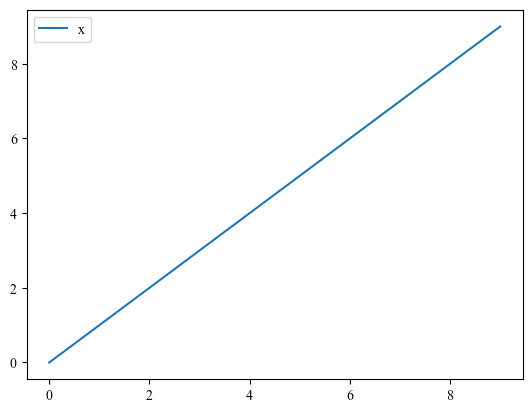

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = '../../times.ttf' # 或绝对路径 '/home/me/fonts/times.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

mpl.rcParams['font.family'] = font_name
plt.plot(range(10),range(10),label='x')
plt.legend()

In [28]:
fine_tuned_cost_lst

[3108.9097905432086,
 3106.738311761126,
 3104.788216261185,
 3103.13219866403,
 3101.5638066526553,
 3100.1055404787103,
 3098.8150489370328,
 3097.5533150641127,
 3096.358246391833,
 3095.2771081776546]

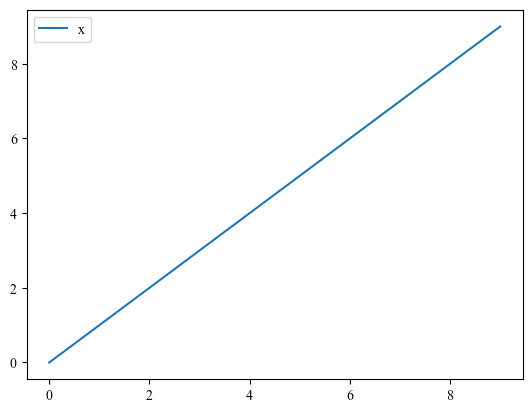

In [29]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
import matplotlib as mpl
from matplotlib import font_manager as fm

font_path = '../../times.ttf' # 或绝对路径 '/home/me/fonts/times.ttf'
fm.fontManager.addfont(font_path)
prop = fm.FontProperties(fname=font_path)
font_name = prop.get_name()

mpl.rcParams['font.family'] = font_name
plt.plot(range(10),range(10),label='x')
plt.legend()

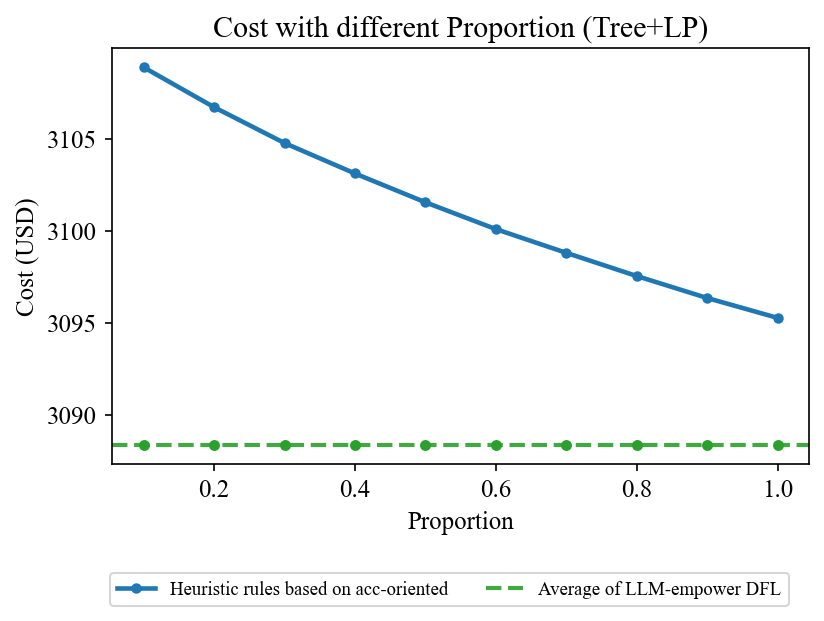

In [30]:
plt.rcParams['font.size'] = 12 

x = np.asarray(prop_list, dtype=float)
y_ft = np.asarray(fine_tuned_cost_lst, dtype=float)

ds, qwen, llama = 3082.25, 3087.14 ,3095.66 
baseline_avg = (ds + qwen + llama) / 3.0

fig, ax = plt.subplots(figsize=(6, 4.2), dpi=150)

ax.plot(x, y_ft, lw=2.2, marker="o", ms=4, color="#1f77b4", label="Heuristic rules based on acc-oriented")
ax.axhline(baseline_avg, ls="--", lw=2.0, color="#2ca02c", alpha=0.9,
           label=f"Average of LLM-empower DFL")

# 如果你想在水平线上也显示一些点，用 scatter（可选）
k = max(1, len(x)//8)
xm = x[::k]
ax.scatter(xm, np.full_like(xm, baseline_avg), s=18, color="#2ca02c", zorder=3)

ax.set_xlabel("Proportion")
ax.set_ylabel("Cost (USD)")
ax.set_title("Cost with different Proportion (Tree+LP)")

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=True, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.subplots_adjust(bottom=0.22)
plt.savefig('../../Figure/Heuristic_Tree_LP.jpg',dpi=1000)
plt.show()